# Term Paper 1 

### Candidates: 66, 56, 54

In [1]:
# Importing necessary libraries for numerical computations, optimization, and plotting
import numpy as np
from scipy.optimize import root_scalar, minimize_scalar
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Setting our visual preferences for matplotlib for consistent and clear plots throughout the notebook
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.style.use('default')

## Part 1 - Euler equation errors

In this part, we implement the objects needed to evaluate the capitalists' Euler equation error. Since the Euler equation is stated in household-level variables, we first restate it in terms of aggregate capital using the market-clearing conditions. We then evaluate the Euler equation error on a grid under the restriction $K_{t+1}=K_t$ to verify that the function has a root.

### 1.1 Define class parameters

In [2]:
# Store model parameters

@dataclass
class Parameters:

    # Household paramters
    beta: float = 0.99**30 #Discount factor
    gamma: float = 2.1 #Relative risk aversion
    phi: float = 0.5 #Fraction of wealth bequeathed by old capitalists

    # Government Parameters
    tau: float = 0.3 #Payroll tax rate 
    tau_a: float = 0.0 # Wealth tax rate (initially 0, will be changed in part 4)  

    # Production Parameters
    alpha: float = 0.36 #Capital share in production
    delta: float = 1.0 - 0.94**30 #Capital decpreciation
    z: float = 1.0  #Total factor productivity (TFP)

    # Population Parameters
    Nw: float = 0.8 #Fraction of workers
    Nk: float = 0.2 #Fraction of capitalists

    # Uncertainty parameters (Relevant for part 6)
    pi_a: float = 0.5
    tau_a_iid: float = 0.05

###  1.2 Implement function euler_err()

First, we restate the Euler equation in terms of aggregate capital. The capitalists' Euler equation is

$u'(c^k_{y,t}) = \beta (1+r_{t+1})(1-\phi)u'(c^k_{o,t+1})
$

Using the budget constraints, this can be written as

$
u'(b_t-a_t)=\beta(1+r_{t+1})(1-\phi)u'((1-\phi)(1+r_{t+1})a_t)
$

To express this in terms of aggregate capital, we use asset-market clearing:

$
K_t = \frac{1}{2}N_k a_{t-1}
$

which implies

$
a_{t-1} = \frac{2K_t}{N_k}, \qquad a_t = \frac{2K_{t+1}}{N_k}
$

The bequest rule then becomes

$
b_t = \phi(1+r_t)a_{t-1}
     = \phi(1+r_t)\frac{2K_t}{N_k}
$

Hence, the Euler equation can be evaluated directly as a function of current and next-period aggregate capital. In the baseline model considered in Part 1, there is no wealth tax, so this corresponds to setting $\tau_a = 0$. Our implementation of `euler_err()` is written in a way that also allows for the later extensions with wealth taxation, but the no-tax case is the relevant benchmark here.

In [3]:
# marginal utility under CRRA preferences
def u_prime(c, gamma):
    """Marginal utility of consumption for CRRA.
    Defining it as a function makes the Euler equation 
    easier to write and avoids repeating c**(-gamma). """
    return c**(-gamma)

In [4]:
def euler_err(K_next, K, par: Parameters):
    """
    Compute the capitalists' Euler equation error for a given capital
    stock today and tomorrow.
    
    Inputs:
    - K_next: Capital stock for period t+1 (scalar)
    - K: Capital stock for period t (scalar)
    - par: Instance of Parameters class containing model constants
    
    Returns:
    - error: Difference between LHS and RHS of the Euler equation
    """
    L_t = par.Nw / 2 # Labor supply is fixed at half of the workers
    k_t = K / L_t # Capital per worker today
    r_t = par.z * par.alpha * k_t**(par.alpha - 1) - par.delta # Interest rate today
    
    k_next = K_next / L_t # Capital per worker tomorrow
    r_next = par.z * par.alpha * k_next**(par.alpha - 1) - par.delta # Interest rate tomorrow
    
    a_prev = 2 * K / par.Nk # Initial wealth of capitalists is proportional to the capital stock today
    a_t = 2 * K_next / par.Nk # Wealth of capitalists tomorrow is proportional to the capital stock tomorrow
    
    # in Part 1, tau_a = 0, so these terms drop out in the baseline model
    Ta_t = par.tau_a * (1 + r_t) * K # Wealth tax revenue today
    Ta_next = par.tau_a * (1 + r_next) * K_next # Wealth tax revenue tomorrow
    
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev # Bequests received by capitalists today
    ck_y_t = b_t + Ta_t - a_t # Consumption of capitalists today
    
    if ck_y_t <= 0:
        return 1e10  # Penalize negative consumption. Arbitrarily large positive error to push the solution away from negative consumption.
        
    ck_o_next = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a_t + Ta_next
    
    if ck_o_next <= 0:
        return -1e10  # Penalize negative consumption. Arbitrarily large negative error to push the solution away from negative consumption.
        
    LHS = u_prime(ck_y_t, par.gamma) # Left-hand side of the Euler equation
    RHS = par.beta * (1 + r_next) * (1 - par.tau_a) * (1 - par.phi) * u_prime(ck_o_next, par.gamma) # Right-hand side of the Euler equation
    
    return LHS - RHS

In [5]:
# initialize parameters
par = Parameters()

# grid for capital under K_{t+1} = K_t
K_grid = np.linspace(0.001, 0.02, 100)

# grid for capital under K_{t+1} = K_t
errors = [euler_err(K, K, par) for K in K_grid]

### 1.3 Plotting the Euler Equation errors

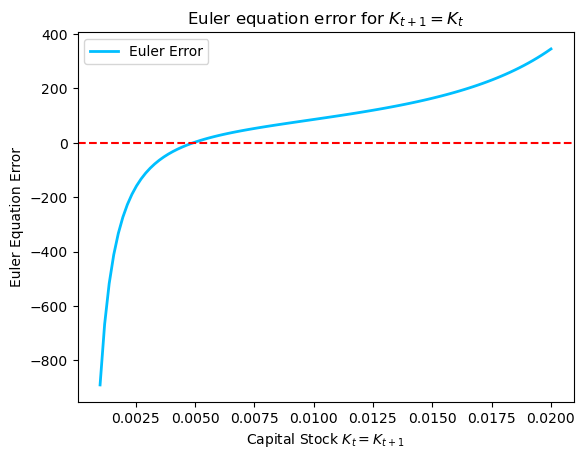

In [6]:
# Plotting Euler equation errors
plt.figure()
plt.plot(K_grid, errors, label='Euler Error', color='deepskyblue', linewidth=2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Capital Stock $K_t = K_{t+1}$')
plt.ylabel('Euler Equation Error')
plt.title('Euler equation error for $K_{t+1}=K_t$')
plt.legend()
plt.show()

### Interpretation

The figure plots the capitalists' Euler equation error as a function of aggregate capital under the restriction $K_{t+1}=K_t$. A root of this function is a capital level at which the left-hand side and right-hand side of the Euler equation are equal, so the capitalists' intertemporal optimality condition is satisfied.

The figure shows that the Euler equation error crosses zero on the chosen interval, which means that there exists at least one candidate steady-state capital stock. This confirms that the implementation of `euler_err()` behaves sensibly and that a root-finding algorithm can be used in Part 2 to solve for the steady state.

Economically, the sign of the Euler equation error shows whether the candidate level of saving is too low or too high relative to the optimal intertemporal allocation of consumption. The zero crossing therefore identifies a capital stock consistent with optimal saving behavior in equilibrium.

## Part 2 - Steady state

In this part, we compute the steady-state equilibrium of the economy. In steady state, all quantities and prices are constant over time, so the equilibrium capital stock $K^*$ must satisfy the Euler equation under the restriction $K_{t+1} = K_t = K^*$. 

We use a root-finding algorithm together with the `euler_err()` function from Part 1 to solve for $K^*$, and then compute the remaining steady-state quantities implied by market clearing and the households' budget constraints.

### 2.1 Storing all steady-state quantities and prices

We store the steady-state allocation and prices in a dedicated dataclass so that the same object can be reused in later parts of the notebook.

In [7]:
@dataclass
class SteadyState:
    """
    Stores all steady-state quantities and prices as required by Task 2.1.
    Calculates derived variables (like annualized rates) during initialization.
    """
    K: float
    Y: float
    w: float
    r: float
    cw_y: float
    cw_o: float
    ck_y: float
    ck_o: float
    a: float
    b: float
    p: float
    L: float
    Ta: float
    st: float
    goods_mkt: float

### 2.2 Implement function that computes and returns steady state

We solve for the steady-state capital stock using a root finder and then compute the remaining equilibrium quantities and prices implied by the model conditions.

In [8]:
# in Part 2, we solve the baseline deterministic steady state
def compute_steady_state(par: Parameters, K_guess=0.01, uncertain=False):
    """
    Computes steady state values using a root-finder to locate the steady-state capital K*.
    """
    if uncertain:
        res = root_scalar(lambda K: euler_err_uncertain(K, K, par), bracket=[1e-5, 1.0])
    else:
        res = root_scalar(lambda K: euler_err(K, K, par), bracket=[1e-5, 1.0])
        
    if not res.converged:
        raise ValueError("Steady state root-finder not converged")
    
    K = res.root # Steady state capital stock
    L = par.Nw / 2 
    k = K / L 
    Y = par.z * K**par.alpha * L**(1 - par.alpha) # Output in steady state
    r = par.z * par.alpha * k**(par.alpha - 1) - par.delta # Interest rate in steady state
    w = par.z * (1 - par.alpha) * k**par.alpha # Wage in steady state
    
    a = 2 * K / par.Nk 
    Ta = par.tau_a * (1 + r) * K 
    b = par.phi * (1 - par.tau_a) * (1 + r) * a
    
    p = par.tau * w
    
    cw_y = (1 - par.tau) * w + Ta
    cw_o = p + Ta
    
    ck_y = b + Ta - a
    ck_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r) * a + Ta
    
    st = a / (b + Ta)
    
    # Validation: goods market clearing check
    # The goods market residual should be numerically close to zero if the computed steady state is correct
    C = (par.Nw / 2) * (cw_y + cw_o) + (par.Nk / 2) * (ck_y + ck_o) # total consumption
    I = par.delta * K # steady-state investment
    goods_mkt = Y - C - I  # goods market residual
    assert abs(Y - C - I) < 1e-4, "Goods market clearing violated."
    
    return SteadyState(K=K, Y=Y, w=w, r=r, cw_y=cw_y, cw_o=cw_o, 
                       ck_y=ck_y, ck_o=ck_o, a=a, b=b, p=p, L=L, Ta=Ta, st=st, goods_mkt = goods_mkt)

### 2.3 Steady state equilibrium for this model

We now report the steady-state allocation and prices, including output, capital, factor prices, and the choices of workers and capitalists.

In [9]:
ss_base = compute_steady_state(par)
# In addition to output, capital, factor prices, and the choices of workers and capitalists
# we also report on other key variables for a compehensive understanding of the steady state
part_2_results = {
    "Steady State Capital (K*)": f"{ss_base.K:.5f}",
    "Output (Y)": f"{ss_base.Y:.5f}",
    "Wage (w)": f"{ss_base.w:.5f}",
    "Net Return on Capital (r)": f"{ss_base.r:.5f}",
    "Young Worker Consumption (cw_y)": f"{ss_base.cw_y:.5f}",
    "Old Worker Consumption (cw_o)": f"{ss_base.cw_o:.5f}",
    "Young Capitalist Consumption (ck_y)": f"{ss_base.ck_y:.5f}",
    "Old Capitalist Consumption (ck_o)": f"{ss_base.ck_o:.5f}",
    " Initial Wealth of Capitalists (a)": f"{ss_base.a:.5f}",
    "Bequests Received by Capitalists (b)": f"{ss_base.b:.5f}",
    "Taxes on Capital (p)": f"{ss_base.p:.5f}",
    "Savings Rate (st)": f"{ss_base.st:.5f}"
}
part_2_results

{'Steady State Capital (K*)': '0.00492',
 'Output (Y)': '0.08213',
 'Wage (w)': '0.13141',
 'Net Return on Capital (r)': '5.16294',
 'Young Worker Consumption (cw_y)': '0.09198',
 'Old Worker Consumption (cw_o)': '0.03942',
 'Young Capitalist Consumption (ck_y)': '0.10246',
 'Old Capitalist Consumption (ck_o)': '0.15168',
 ' Initial Wealth of Capitalists (a)': '0.04922',
 'Bequests Received by Capitalists (b)': '0.15168',
 'Taxes on Capital (p)': '0.03942',
 'Savings Rate (st)': '0.32452'}

### 2.4 Annualized net interest rate

One model period corresponds to 30 years. We therefore convert the model-period net interest rate $r$ into an annualized net interest rate using

$
1 + r^{ann} = (1+r)^{1/30}
$

so that

$
r^{ann} = (1+r)^{1/30} - 1
$

This makes the implied return easier to assess economically.

In [10]:
annualized_r = (1 + ss_base.r)**(1/30) - 1
print(f"Implied annualized net interest rate: {annualized_r:.4%}")

Implied annualized net interest rate: 6.2493%


### Interpretation

The steady state is obtained by finding the capital stock $K^*$ such that the capitalists' Euler equation holds under the restriction $K_{t+1}=K_t$. Once this capital stock is determined, the remaining steady-state quantities follow from firms' first-order conditions, the government budget constraint, and the households' budget constraints.

The reported goods market residual is numerically very close to zero, which confirms that the computed allocation is internally consistent and satisfies the equilibrium conditions of the model. This is an important verification step, as required in the assignment.

The implied annualized net interest rate is easier to interpret economically than the raw model-period interest rate, since one model period corresponds to 30 years. If the annualized rate lies in a reasonable range, this supports that the steady-state solution is economically sensible.

## Part 3 - Transition dynamics

In this part, we compute the transition path of the economy outside the steady state. Starting from an initial capital stock below the steady-state level, we simulate the equilibrium dynamics for $T=20$ periods. Since the current capital stock $K_t$ is predetermined in each period, the next-period capital stock $K_{t+1}$ can be found by solving the capitalists' Euler equation with a root finder period by period.

### 3.1 Storing the simulated time series of all model variables

We store the simulated variables in a dedicated dataclass so that the transition paths can be reused in both the reporting and the plotting code.

In [11]:
@dataclass
class Simulation:
    K: np.ndarray
    Y: np.ndarray
    w: np.ndarray
    r: np.ndarray
    cw_y: np.ndarray
    cw_o: np.ndarray
    ck_y: np.ndarray
    ck_o: np.ndarray
    a: np.ndarray
    b: np.ndarray
    st: np.ndarray
    goods_mkt: np.ndarray

### 3.2 Implement function to compute transition path

We use a root finder in each period to solve for $K_{t+1}$, taking the current capital stock $K_t$ as predetermined. We then verify the transition path using the goods market clearing condition period by period.

In [12]:
def simulate_olg(K0, T, par: Parameters, uncertain=False):
    """
    Computes transition path from initial capital stock K0 for T periods.
    """
    
    # initialize capital path
    K = np.zeros(T + 1)
    K[0] = K0

    # solve for next-period capital period by period
    for t in range(T):
        # use the appropriate Euler equation
        if uncertain:
            res = root_scalar(lambda K_next: euler_err_uncertain(K_next, K[t], par), bracket=[1e-5, 1.0], method="brentq")
        else:
            res = root_scalar(lambda K_next: euler_err(K_next, K[t], par), bracket=[1e-5, 1.0], method="brentq")
        K[t+1] = res.root

    # current and next-period capital
    K_t = K[:-1]
    K_next = K[1:]

    # aggregate labor supply
    L = par.Nw / 2
    Y = par.z * K_t**par.alpha * L**(1 - par.alpha)
    r = par.z * par.alpha * (K_t / L)**(par.alpha - 1) - par.delta
    w = par.z * (1 - par.alpha) * (K_t / L)**par.alpha
    
    a = 2 * K_next / par.Nk
    a_prev = 2 * K_t / par.Nk

    # transfers and bequests
    Ta = par.tau_a * (1 + r) * K_t
    b = par.phi * (1 - par.tau_a) * (1 + r) * a_prev
    
    st = a / (b + Ta)
    
    p = par.tau * w
    cw_y = (1 - par.tau) * w + Ta
    cw_o = p + Ta
    ck_y = b + Ta - a
    ck_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r) * a_prev + Ta

    # goods clearing
    C = (par.Nw / 2) * (cw_y + cw_o) + (par.Nk / 2) * (ck_y + ck_o) # total consumption
    I = K_next - (1 - par.delta) * K_t # investment
    goods_mkt = Y - C - I # goods market residual
    
    # verify goods market clearing
    assert np.all(np.abs(goods_mkt) < 1e-4), "Goods market clearing violated during transition."
        
    return Simulation(K=K_t, Y=Y, w=w, r=r, cw_y=cw_y, cw_o=cw_o, 
                      ck_y=ck_y, ck_o=ck_o, a=a, b=b, st=st, goods_mkt=goods_mkt)

###  3.3 Simulating the transition path

To verify the steady state from Part 2, we simulate the economy starting from an initial capital stock equal to one half of the steady-state capital stock. If the previous computations are correct, the economy should converge back to the steady state over time. Because the economy starts below the steady state, we expect output and wages to start below their steady-state levels, while the return on capital should initially be above steady state. 

In [13]:
# Simulate from K0 = K*/2 for 20 periods
sim_base = simulate_olg(ss_base.K / 2, T=20, par=par)
print(f"Maximum absolute goods market residual: {np.max(np.abs(sim_base.goods_mkt)):.8e}")

Maximum absolute goods market residual: 2.51534904e-17


### 3.4 Plotting the transition path

We plot the simulated series for output, capital, wages, the interest rate, bequests, the savings rate, and
the consumption of young and old workers and capitalists. Following the instructions, all variables except
for the interest rate $r_t$ and the savings rate $s_t$ are shown as percent deviations from steady state,
while $r_t$ and $s_t$ are shown in percent. The plotting style follows the week 7 workshop figures, with steady-state reference lines included forcomparison.

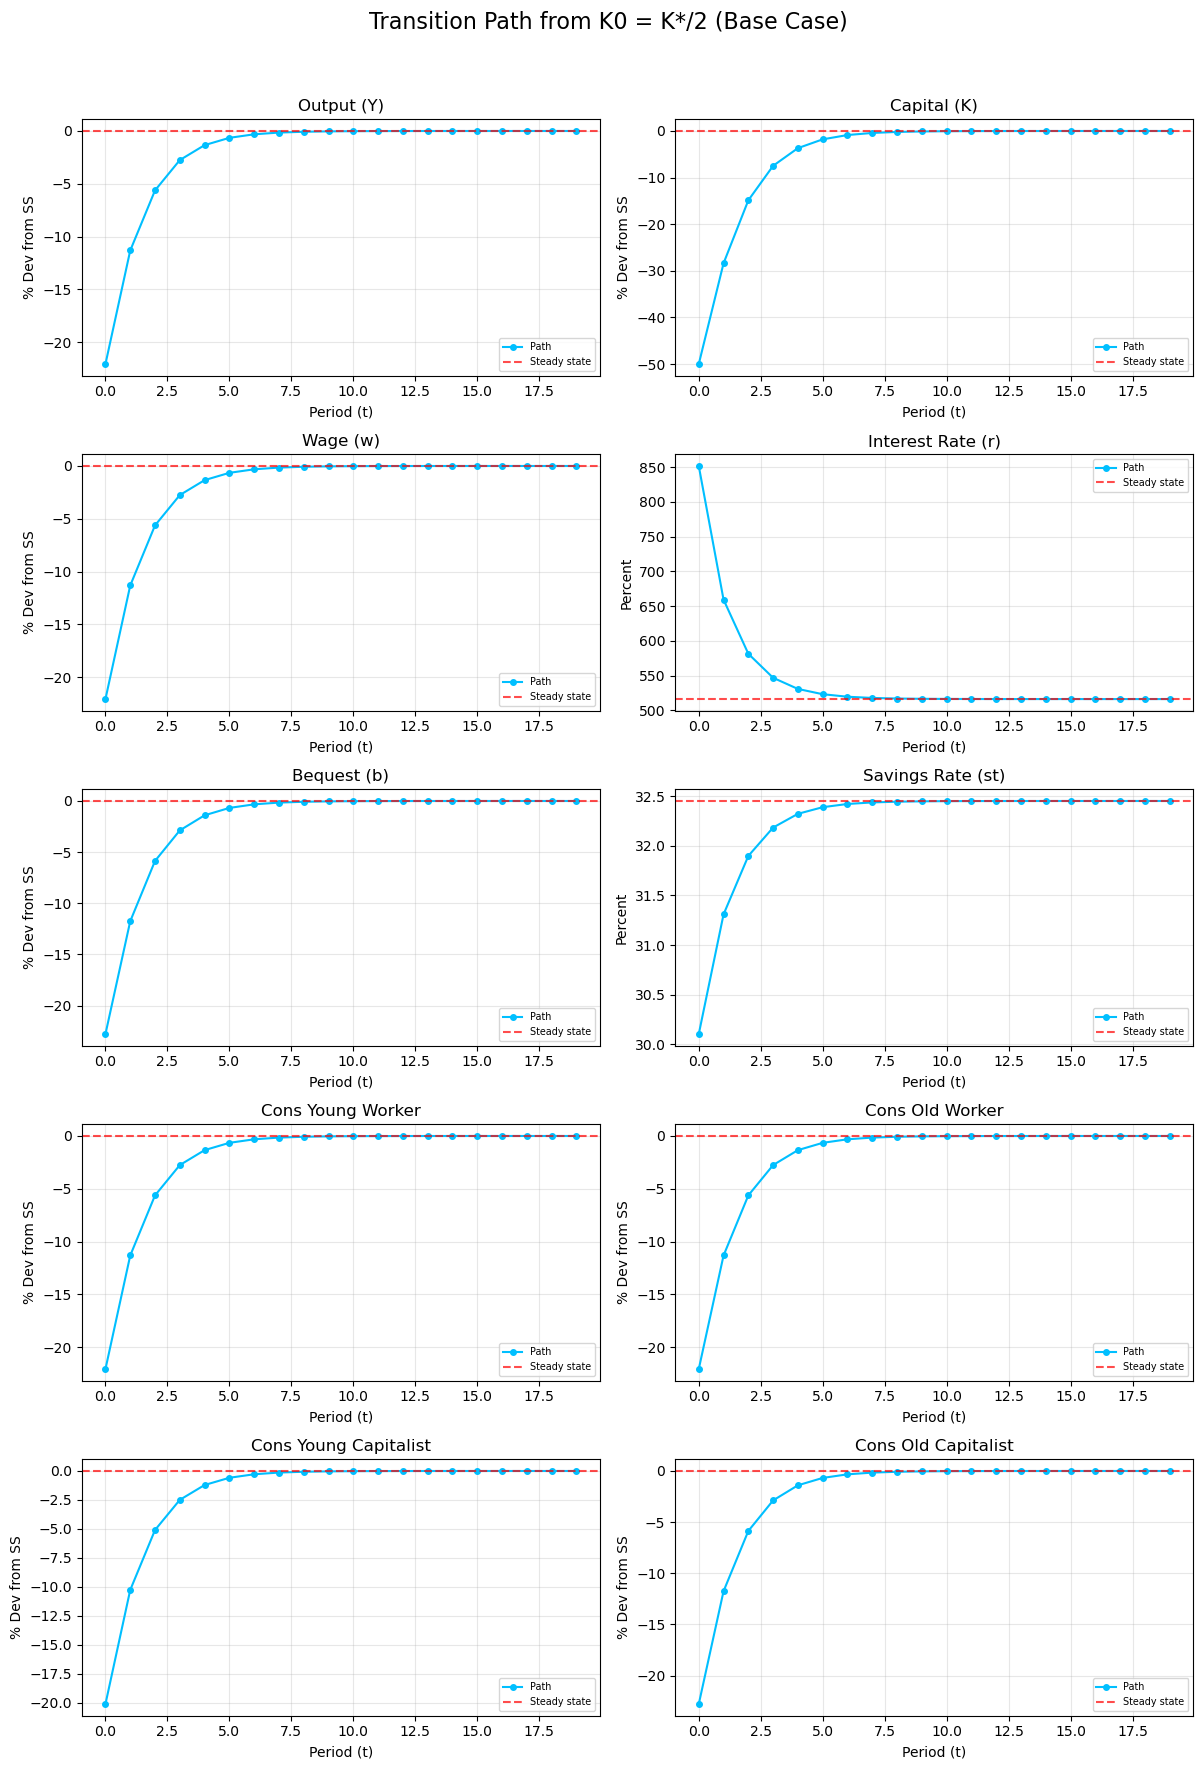

In [26]:
def plot_simulation(sim, ss, title, ss_old=None):
    variables = ['Y', 'K', 'w', 'r', 'b', 'st', 'cw_y', 'cw_o', 'ck_y', 'ck_o']
    labels = ['Output (Y)', 'Capital (K)', 'Wage (w)', 'Interest Rate (r)', 
              'Bequest (b)', 'Savings Rate (st)', 'Cons Young Worker', 
              'Cons Old Worker', 'Cons Young Capitalist', 'Cons Old Capitalist']
    
    fig, axes = plt.subplots(5, 2, figsize=(12, 18))
    axes = axes.flatten()
    
    for i, var in enumerate(variables):
        ax = axes[i]
        path = getattr(sim, var)
        ss_val = getattr(ss, var)
        
        # use percent for interest rate and savings rate
        if var in ['r', 'st']:
            dev_path = 100 * path
            ss_line = 100 * ss_val
        else:
            dev_path = (path / ss_val - 1) * 100
            ss_line = 0.0
        
        # If we have an old SS, prepend it as "Period -1" to show the starting point of the transition.
        # Allows us to visualize a before, during, and after the tax introduction in one plot.
        if ss_old is not None:
            ss_old_val = getattr(ss_old, var)
            
            if var in ['r', 'st']:
                old_dev = 100 * ss_old_val
            else:
                old_dev = (ss_old_val / ss_val - 1) * 100
            
            # Combine: Period -1 is Old SS, then the simulation path follows
            full_path = np.insert(dev_path, 0, old_dev)
            time_axis = np.arange(-1, len(path))
            ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Tax Introduction')
            
            ax.plot(time_axis, full_path, marker='o', color='deepskyblue', label='Path', markersize=4)
            ax.axhline(old_dev, color='gray', linestyle=':', alpha=0.8, label='Old SS (Base)')
        else:
            ax.plot(range(len(path)), dev_path, marker='o', color='deepskyblue', label='Path', markersize=4)
        
        # New Steady State is always 0
        ax.axhline(ss_line, color='red', linestyle='--', alpha=0.7, label='Steady state')
        
        ax.set_title(labels[i])
        ax.set_xlabel('Period (t)')
        
        if var in ['r', 'st']:
            ax.set_ylabel('Percent')
        else:
            ax.set_ylabel('% Dev from SS')
            
        ax.legend(fontsize='x-small')
        ax.grid(True, alpha=0.3)
        
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
plot_simulation(sim_base, ss_base, title="Transition Path from K0 = K*/2 (Base Case)")

### Interpretation

The economy starts with a capital stock below the steady-state level, so output and wages are initially below their steady-state values. At the same time, capital is relatively scarce, which implies a high marginal product of capital and therefore a relatively high interest rate.

As the economy evolves, the capital stock increases toward its steady-state value. This raises output, wages, and bequests over time, while the interest rate gradually falls back toward its steady-state level. The consumption levels of workers and capitalists also converge to their steady-state values as the equilibrium allocation adjusts period by period.

Overall, the transition paths behave as expected economically and confirm that the economy converges back to the steady state from Part 2. In addition, the goods market residual is numerically close to zero in all periods, which confirms that the simulated transition path is consistent with the equilibrium conditions of the model.

## Part 4 – Introduction of a wealth tax

In this part, we extend the model to include a wealth tax on old capitalists. Rather than writing a separate implementation from scratch, we adapt the functions from Parts 1–3 so that the same code can handle both the case without a wealth tax, $\tau_a = 0.05$, and the case with a positive wealth tax,
$\tau_a > 0$.

The tax revenue is redistributed lump-sum to all households, so the wealth tax affects both the saving incentives of capitalists and the transfers received by households. We first compute the new steady state with the wealth tax and then simulate the transition path when the economy starts in the original steady state without the tax and the policy is introduced unexpectedly in period $t=0$.

### 4.1 Add wealth tax rate to Parameters

To extend the model, we add a wealth tax rate $\tau_a$ to the parameter class. This allows us to use the same functions from the earlier parts for both the no-tax economy and the taxed economy.

In [15]:
# Introduce a wealth tax
par_tax = Parameters(tau_a=0.05) # wealth-tax economy
ss_tax = compute_steady_state(par_tax) # steady state with wealth tax

### 4.2 Updating the equilibrium conditions

The wealth tax changes the transfer formula, the bequest rule, the capitalists’ Euler equation, and the savings-rate definition. In the code, however, these changes are already embedded in the more general functions from the earlier parts. The no-tax economy is obtained simply by setting $\tau_a = 0$, in which case the tax-related terms drop out.

This means that we do not need to write a separate implementation for the taxed economy. Instead, we can use the same functions as before and solve the model under a positive tax rate.

### 4.3 New steady state with a wealth tax

We now set the wealth tax to $\tau_a = 0.05$, and compute the new steady state.

In [16]:
part_4_results = {
    "Steady State Capital with Tax (K*)": f"{ss_tax.K:.5f}",
    "Output with Tax (Y)": f"{ss_tax.Y:.5f}",
    "Wage with Tax (w)": f"{ss_tax.w:.5f}",
    "Net Return on Capital with Tax (r)": f"{ss_tax.r:.5f}",
    "Savings rate with Tax (s)": f"{ss_tax.st:.5f}",
    "Young Worker Consumption with Tax (cw_y)": f"{ss_tax.cw_y:.5f}",
    "Old Worker Consumption with Tax (cw_o)": f"{ss_tax.cw_o:.5f}",
    "Young Capitalist Consumption with Tax (ck_y)": f"{ss_tax.ck_y:.5f}",
    "Old Capitalist Consumption with Tax (ck_o)": f"{ss_tax.ck_o:.5f}",
    "Goods market residual": f"{ss_tax.goods_mkt:.8e}",
}
part_4_results

{'Steady State Capital with Tax (K*)': '0.00457',
 'Output with Tax (Y)': '0.07998',
 'Wage with Tax (w)': '0.12796',
 'Net Return on Capital with Tax (r)': '5.45335',
 'Savings rate with Tax (s)': '0.32283',
 'Young Worker Consumption with Tax (cw_y)': '0.09105',
 'Old Worker Consumption with Tax (cw_o)': '0.03986',
 'Young Capitalist Consumption with Tax (ck_y)': '0.09591',
 'Old Capitalist Consumption with Tax (ck_o)': '0.14163',
 'Goods market residual': '2.16840434e-18'}

#### Intuition of savings rate and capital stock in new steady state

Relative to the no-tax economy, the wealth tax lowers the after-tax return to saving for capitalists. This reduces their incentive to accumulate wealth, which tends to lower both the savings rate and the steady-state capital stock. Since capital is lower in the new steady state, output and wages are also affected through the firms’ factor-demand conditions.

At the same time, the tax revenues are redistributed as lump-sum transfers to all households. This provides an offsetting force, especially for workers and for capitalists when young. The overall effect on steady-state quantities therefore reflects the trade-off between weaker saving incentives and higher transfers.

### 4.4 & 4.5 Transition after the surprise tax reform

Next, we simulate the transition path when the economy starts in the original steady state without a wealth tax, and the wealth tax is introduced unexpectedly in period $t=0$. Because the policy is applied immediately to the wealth carried into period $t=0$, the reform affects transfers and household choices right away.

We plot the same variables as in Part 3. As before, all quantities except the interest rate and the savings rate are shown as percent deviations. To verify convergence, we indicate both the old steady state without a wealth tax and the new steady state with a wealth tax.

Maximum absolute goods market residual: 2.77555756e-17


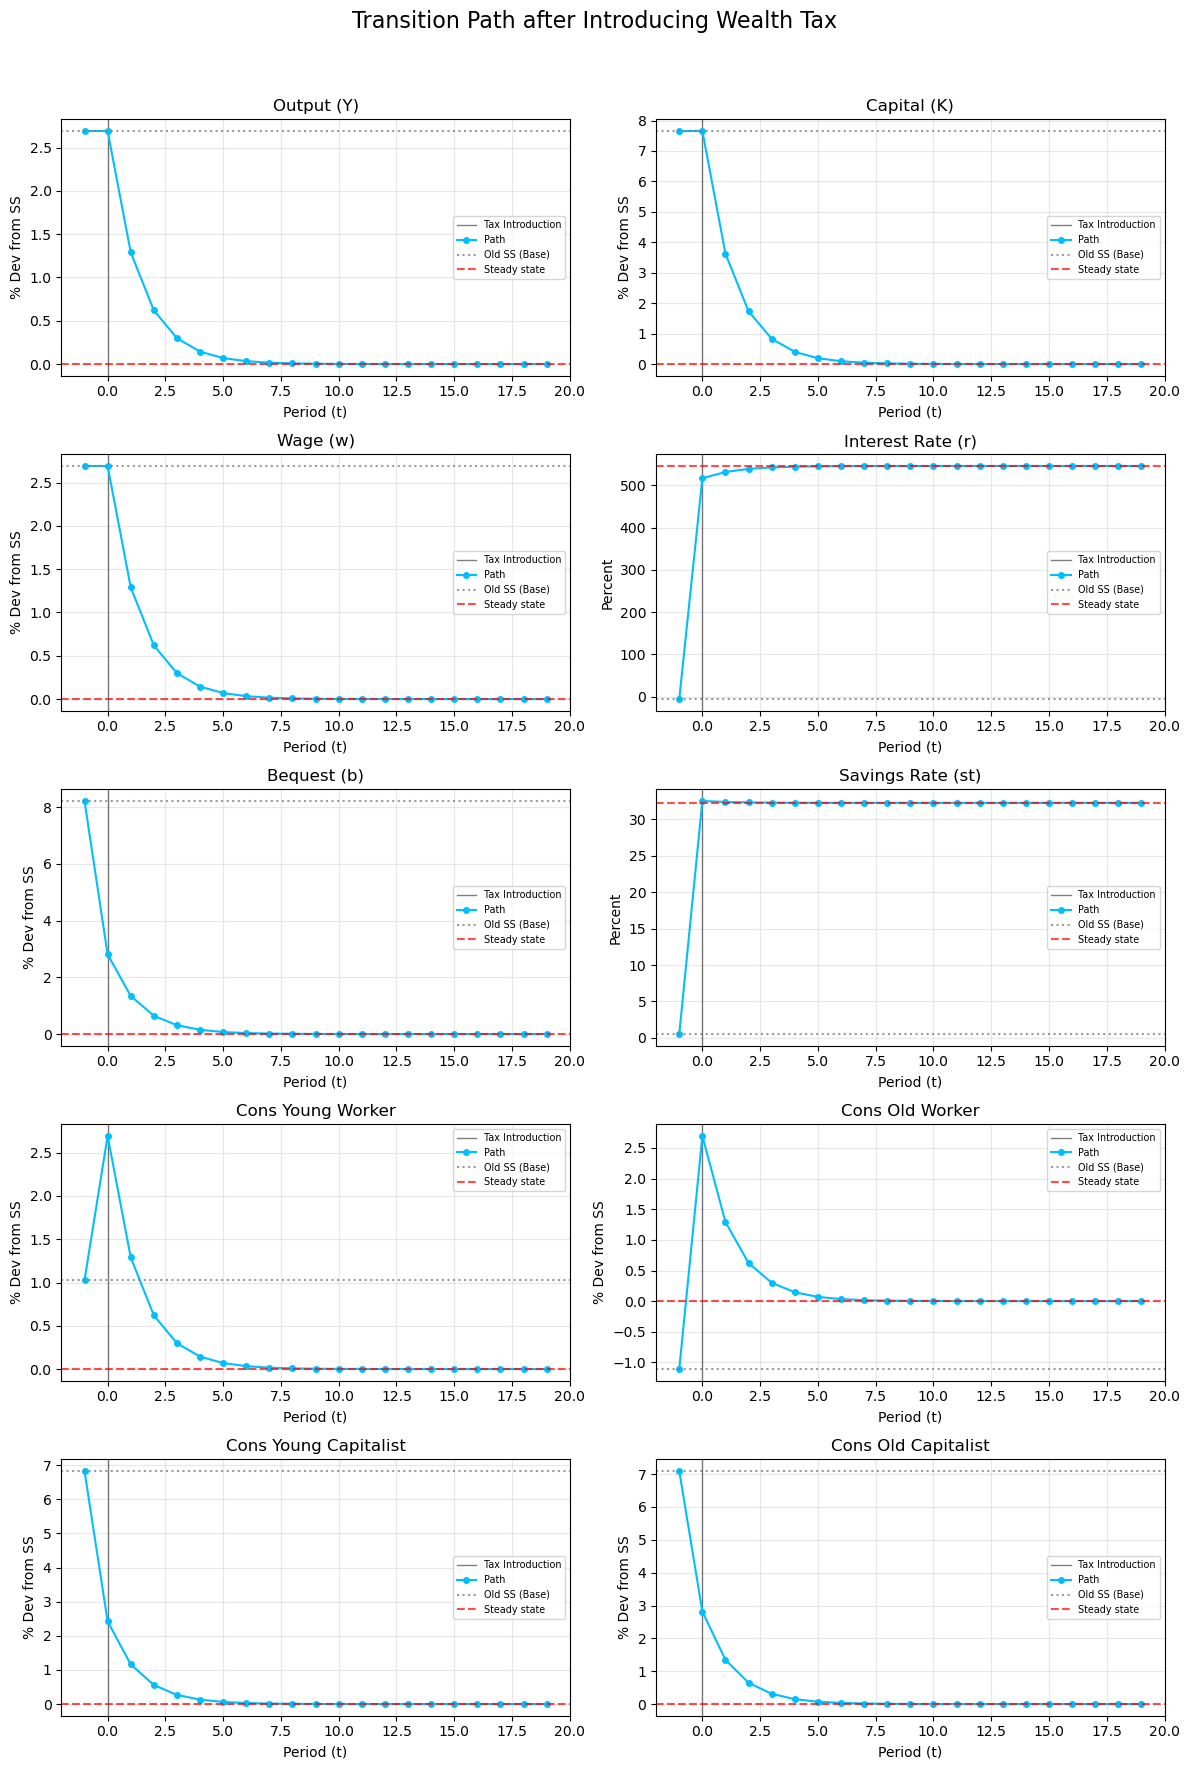

In [17]:
# the economy runs with `par` (no tax) and starts in `ss_base`
# in t=0, the tax `par_tax` is enacted
sim_tax = simulate_olg(ss_base.K, T=20, par=par_tax)

print(f"Maximum absolute goods market residual: {np.max(np.abs(sim_tax.goods_mkt)):.8e}")

plot_simulation(
    sim_tax,
    ss_tax,
    title="Transition Path after Introducing Wealth Tax",
    ss_old=ss_base
)

### 4.6 Discussion

The surprise introduction of the wealth tax creates distinct winners and losers across generations. The current old at $t=0$ are likely to lose the most on impact, since the tax is applied immediately to already accumulated wealth and they have no opportunity to adjust their previous saving decisions. Their old-age consumption therefore falls right away.

For the young generation at $t=0$, the effects are more mixed. On the one hand, they benefit from the lump-sum transfer. On the other hand, they face lower bequests and a lower after-tax return on future savings. The transition paths therefore reflect a trade-off between redistribution and weaker saving incentives.

In the long run, the tax discourages capital accumulation and leads to a lower steady-state capital stock. This reduces output and wages relative to the no-tax economy, while the return on capital rises because capital becomes scarcer. The long-run effects therefore depend on whether a household benefits more from the redistributed transfers or loses more from lower capital accumulation and lower labor income.

## Part 5 – Social welfare and the optimal wealth tax

In this part, we evaluate whether the average household benefits from the introduction of the wealth tax. To simplify the analysis, we ignore the transition path and compare steady states only. Following the assignment, we use a utilitarian social welfare function that computes the weighted average of utilities across young and old workers and capitalists.

### 5.1 Social welfare with and without wealth tax

For the economy without a wealth tax, social welfare is given by

$
SW_{\tau_a = 0}
=
\frac{1}{2}N_w \left(U_y^w + U_o^w\right)
+
\frac{1}{2}N_k \left(U_y^k + U_o^k\right)
$

where $U_y^w$ is the lifetime utility of a young worker, $U_o^w = u(c_o^w)$ is the utility of an old worker, $U_y^k$ is the lifetime utility of a young capitalist, and $U_o^k = u(c_o^k)$ is the utility of an old capitalist. For the economy with a wealth tax, we compute welfare analogously using the steady-state consumption levels under the tax. We therefore compute both total social welfare and the utility contributions of each household type in the two steady states.

In [18]:
# Compute CRRA utility
def util(c, gamma):
    # log utility case
    if gamma == 1:
        return np.log(c)
    
    # CRRA utility
    return (c**(1 - gamma)) / (1 - gamma)

In [19]:
# Compute utilitarian social welfare in steady state
def social_welfare(par: Parameters):
    ss = compute_steady_state(par)

    # life-cycle utility evaluated at steady state
    Uw_y = util(ss.cw_y, par.gamma) + par.beta * util(ss.cw_o, par.gamma)
    Uw_o = util(ss.cw_o, par.gamma)

    Uk_y = util(ss.ck_y, par.gamma) + par.beta * util(ss.ck_o, par.gamma)
    Uk_o = util(ss.ck_o, par.gamma)

    # utilitarian social welfare
    SW = (par.Nw / 2) * (Uw_y + Uw_o) + (par.Nk / 2) * (Uk_y + Uk_o)

    return SW, Uw_y, Uw_o, Uk_y, Uk_o

#### Comparing welfare with and without the wealth tax

We first compare the steady state without a wealth tax to the steady state with the wealth tax from Part 4. This tells us whether the average household prefers the no-tax economy or the taxed economy when we ignore transition dynamics. We also compare the utility levels of young and old workers and capitalists to see which household types drive the overall welfare ranking.

In [20]:
SW_base, Uw_y_base, Uw_o_base, Uk_y_base, Uk_o_base = social_welfare(par)
SW_tax, Uw_y_tax, Uw_o_tax, Uk_y_tax, Uk_o_tax = social_welfare(par_tax)

print(f"Social welfare (tau_a = 0.00): {SW_base:.4f}")
print(f"Social welfare (tau_a = 0.05): {SW_tax:.4f}")
print()
print(f"Young workers:      {Uw_y_base:.4f} -> {Uw_y_tax:.4f}")
print(f"Old workers:        {Uw_o_base:.4f} -> {Uw_o_tax:.4f}")
print(f"Young capitalists:  {Uk_y_base:.4f} -> {Uk_y_tax:.4f}")
print(f"Old capitalists:    {Uk_o_base:.4f} -> {Uk_o_tax:.4f}")

Social welfare (tau_a = 0.00): -29.5652
Social welfare (tau_a = 0.05): -29.5342

Young workers:      -36.1159 -> -35.9704
Old workers:        -31.8636 -> -31.4751
Young capitalists:  -16.4970 -> -17.7561
Old capitalists:    -7.2375 -> -7.8044


### 5.2 Finding the socially optimal wealth tax

Next, we maximize social welfare as a function of the wealth tax rate $\tau_a$. For each candidate tax
rate, we solve for the corresponding steady state and then evaluate the utilitarian welfare function at that
steady state.

In [21]:
# objective: negative social welfare
def objective_tau(tau):
    par_tmp = Parameters(tau_a=tau)
    SW, _, _, _, _ = social_welfare(par_tmp)
    return -SW

# find welfare-maximizing tax rate
res_opt = minimize_scalar(objective_tau, bounds=(0.0, 0.20), method='bounded')
tau_opt = res_opt.x

print(f"Optimal wealth tax rate: {tau_opt:.4f}")

Optimal wealth tax rate: 0.0406


We use the welfare-maximizing tax rate $\tau_a^*$ to solve for the associated steady state and compare
it to the original steady state without a wealth tax.

### 5.3 Steady state at the optimal wealth tax

Finally, we solve for the steady state associated with the welfare-maximizing tax rate $\tau_a^*$ and compare output and capital to the original steady state without a wealth tax. We report the percentage changes in $Y$ and $K$ relative to the no-tax benchmark.

In [22]:
par_opt = Parameters(tau_a=tau_opt)
ss_opt = compute_steady_state(par_opt)

pct_Y = (ss_opt.Y - ss_base.Y) / ss_base.Y * 100
pct_K = (ss_opt.K - ss_base.K) / ss_base.K * 100

print(f"Optimal wealth tax rate (tau_a*): {tau_opt:.4f}")
print(f"Output change (Y) at tau*: {pct_Y:.2f}%")
print(f"Capital change (K) at tau*: {pct_K:.2f}%")

Optimal wealth tax rate (tau_a*): 0.0406
Output change (Y) at tau*: -2.12%
Capital change (K) at tau*: -5.78%


### Interpretation

A lower level of output and capital can still be welfare-maximizing because the utilitarian welfare criterion depends on households’ consumption utilities rather than aggregate production alone. The wealth tax reduces saving incentives and lowers capital accumulation, but it also redistributes resources through lump-sum transfers to all households.

Whether social welfare rises therefore depends on the balance between two effects. On the one hand, lower capital tends to reduce output and wages. On the other hand, the redistribution generated by the tax can improve the consumption allocation across households and across the life cycle. If these redistribution gains outweigh the loss from lower aggregate production, the taxed steady state can deliver higher social welfare even when both $Y$ and $K$ are lower than in the no-tax benchmark.

Comparing the two steady states tells us whether the average household prefers the taxed economy or the no-tax economy when transition dynamics are ignored. Looking at the utility levels of each household type also shows whether the welfare ranking is mainly driven by workers, capitalists, or specific age groups.

## Part 6 – Uncertainty about wealth taxes

In this part, we consider the case where future wealth tax policy is uncertain. We assume that the actual wealth tax in the current period remains zero, but households believe that next period’s wealth tax may be positive with some probability. Since the future tax is IID, this uncertainty affects expectations about future after-tax returns and transfers, but not the current tax policy itself.

To solve this extension, we do not write a separate version of the whole model. Instead, we adapt the earlier implementation so that the same steady-state and simulation code can work both with and without policy uncertainty.

### 6.1 Include new attributes

To introduce uncertainty about future wealth taxes, we extend the parameter class with the probability that a positive wealth tax is enacted next period and with the corresponding uncertain tax rate. This allows the same model structure to be used in both the deterministic and the stochastic environment.

The new uncertainty parameters are included directly in the `Parameters` dataclass defined earlier in thenotebook. In particular, we use 

$\pi_a = 0.5$ 

$\tau_a^{iid} = 0.05$.

### 6.2 Expected Euler equation under tax uncertainty

With uncertainty about next period’s tax policy, the capitalist no longer compares current marginal utility to a single deterministic next-period payoff. Instead, the Euler equation contains an expectation over the two possible tax realizations next period:

$
u'(b_t + T_{a,t} - a_t)
=\beta (1+r_{t+1})(1-\phi)E \left[(1-\tau_{a,t+1})u'\left((1-\phi)(1-\tau_{a,t+1})(1+r_{t+1})a_t + T_{a,t+1}\right)\right]
$

Because the wealth tax process is IID, next period’s tax is equal to $0$ with probability $1-\pi_a$ and equal to $\tau_a^{iid}$ with probability $\pi_a$. We therefore evaluate the expectation directly as a probability-weighted average across the two possible states.

In [23]:
def euler_err_uncertain(K_next, K, par: Parameters):
    """
    Evaluates the Euler error under uncertainty about tau_a in t+1. 
    It evaluates two states in t+1 with respective probabilities.
    """
    # prices today and tomorrow
    L_t = par.Nw / 2
    k_t = K / L_t
    r_t = par.z * par.alpha * k_t**(par.alpha - 1) - par.delta
    
    k_next = K_next / L_t
    r_next = par.z * par.alpha * k_next**(par.alpha - 1) - par.delta

    # current assets and savings
    a_prev = 2 * K / par.Nk
    a_t = 2 * K_next / par.Nk
    
    # current period consumption is known
    Ta_t = par.tau_a * (1 + r_t) * K
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev
    ck_y_t = b_t + Ta_t - a_t
    
    if ck_y_t <= 0: return 1e10
    
    # expected Marginal Utility via Expectation Operator for t+1:
    
    # scenario 1: Wealth Tax Enacted
    tau_1 = par.tau_a_iid # 0.05
    Ta_next_1 = tau_1 * (1 + r_next) * K_next
    ck_o_next_1 = (1 - par.phi) * (1 - tau_1) * (1 + r_next) * a_t + Ta_next_1
    
    # scenario 2: No Wealth Tax
    tau_2 = 0.0
    Ta_next_2 = tau_2 * (1 + r_next) * K_next
    ck_o_next_2 = (1 - par.phi) * (1 - tau_2) * (1 + r_next) * a_t + Ta_next_2
    
    if ck_o_next_1 <= 0 or ck_o_next_2 <= 0:
        return -1e10
        
    E_term = par.pi_a * (1 - tau_1) * u_prime(ck_o_next_1, par.gamma) +              (1 - par.pi_a) * (1 - tau_2) * u_prime(ck_o_next_2, par.gamma)
             
    LHS = u_prime(ck_y_t, par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.phi) * E_term
    
    return LHS - RHS

### 6.3 New steady state under tax uncertainty

We now solve for the steady state when future tax policy is uncertain, but the actual wealth tax remains zero forever. Relative to Part 2, the only change is that households now make saving decisions using the expected Euler equation instead of the deterministic one.

We compare this new steady state to the original deterministic steady state from Part 2 in order to see whether uncertainty about future taxation affects equilibrium saving behavior even when no wealth tax is actually imposed.

In [24]:
# Solve the steady state under the assumption that tau_a = 0 today forever,
# but expected tau_a next period is uncertain.
ss_uncert = compute_steady_state(par, uncertain=True)

print("--- Steady State with Tax Policy Uncertainty ---")
print(f"Capital K:         {ss_uncert.K:.5f} (Base K = {ss_base.K:.5f})")
print(f"Output Y:          {ss_uncert.Y:.5f} (Base Y = {ss_base.Y:.5f})")
print(f"Interest rate r:   {ss_uncert.r:.5f} (Base r = {ss_base.r:.5f})")
print(f"Savings rate s:    {ss_uncert.st:.5f} (Base s = {ss_base.st:.5f})")
print(f"Goods mkt resid.:  {ss_uncert.goods_mkt:.8e}")

--- Steady State with Tax Policy Uncertainty ---
Capital K:         0.00499 (Base K = 0.00492)
Output Y:          0.08254 (Base Y = 0.08213)
Interest rate r:   5.11007 (Base r = 5.16294)
Savings rate s:    0.32733 (Base s = 0.32452)
Goods mkt resid.:  -1.30104261e-17


### 6.4 Transition with tax uncertainty

Next, we simulate the economy when future tax policy becomes uncertain in period $t=0$, while the actual wealth tax remains equal to zero in every period. As in the steady-state calculation, the only conceptual change relative to earlier parts is that households now choose savings using the expected Euler equation.

We start from the original steady state from Part 2 and simulate the economy for $T=20$ periods. The transition paths therefore show how equilibrium quantities respond when expectations about future tax policy change, even though the realized tax path does not.

Maximum absolute goods market residual: 2.94902991e-17


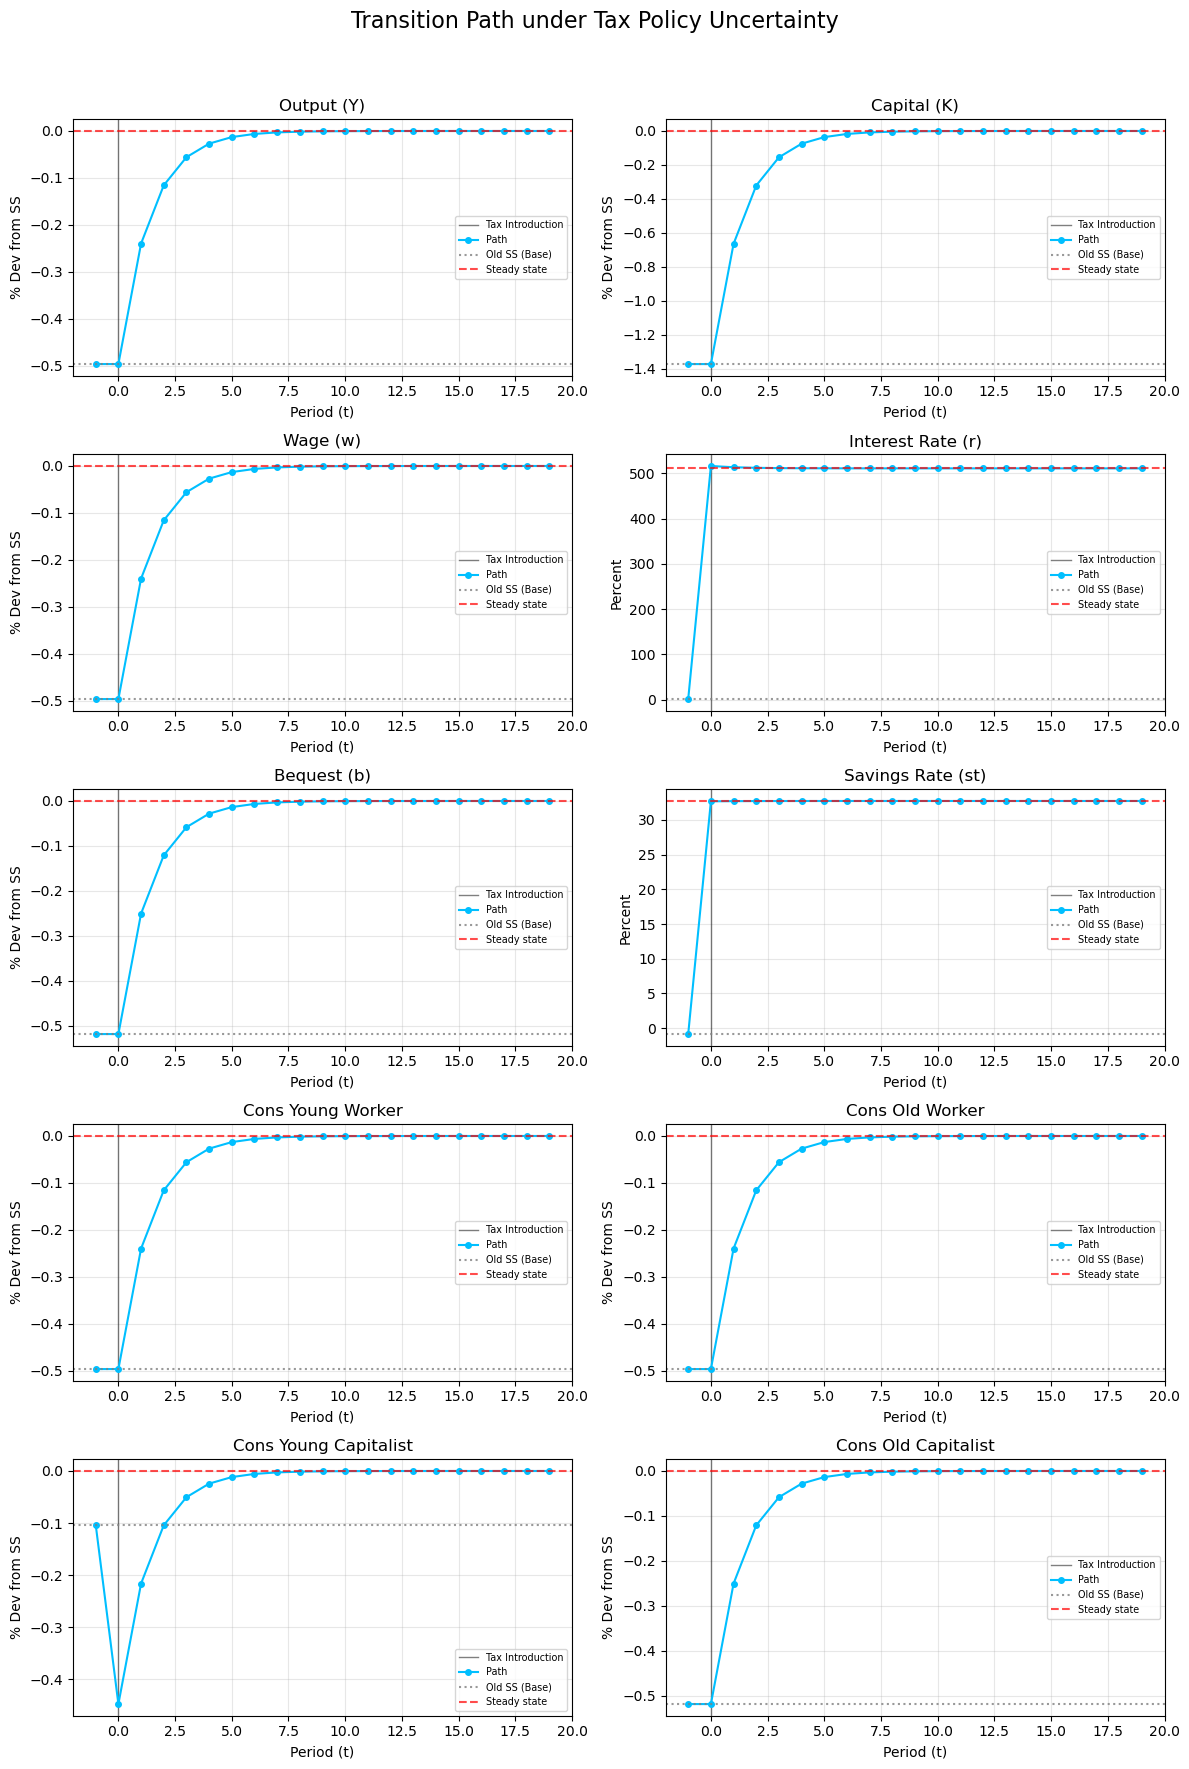

In [25]:
# Simulate transition path where uncertainty hits in t=0, but tau remains 0.
sim_uncert = simulate_olg(ss_base.K, T=20, par=par, uncertain=True)

print(f"Maximum absolute goods market residual: {np.max(np.abs(sim_uncert.goods_mkt)):.8e}")

# Plot transition
plot_simulation(sim_uncert, ss_uncert, title="Transition Path under Tax Policy Uncertainty", ss_old=ss_base)

### 6.5 Interpretation

The steady state under policy uncertainty differs from the deterministic no-tax steady state from Part 2, even though the realized wealth tax remains zero. The reason is that households now make saving decisions based on the expected Euler equation, so future tax risk affects current intertemporal choices.

Relative to Part 2, the new steady state shows that expectations alone can change equilibrium capital accumulation, output, and prices. Relative to Part 4, however, the effect is weaker because the wealth tax is not actually imposed every period. The economy therefore responds to the possibility of future taxation rather than to a realized tax burden today.

More generally, this part shows that anticipated policy risk can matter even when current policy is unchanged. In this model, equilibrium outcomes depend not only on realized taxes, but also on how households form expectations about future after-tax returns and future transfers.